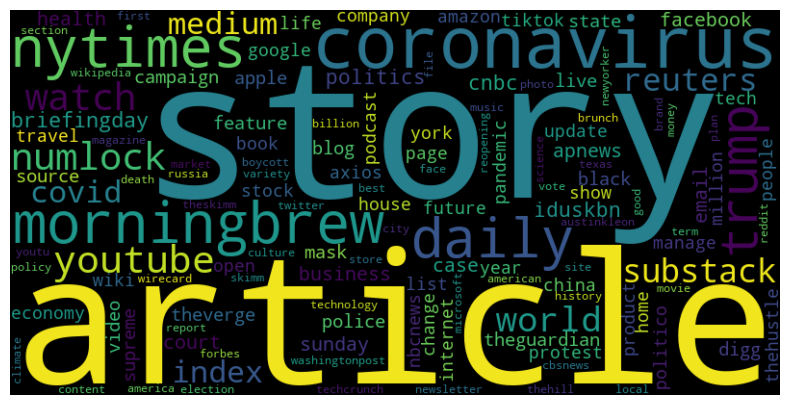

Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
---------------------------------------------
Baseline Accuracy : 89.03%
Optimized Accuracy: 87.97%
---------------------------------------------

Prediction Results:
https://briefingday.us8.list-manage.com/unsubscribe --> SPAM
https://briefingday.com/fan --> SAFE
https://www.infowars.com/p_p_p/ --> SPAM
https://www.cnn.com/world --> SAFE
https://paypal.com.scam-verification.ru --> SPAM
https://github.com/v2/pulls --> SAFE


In [34]:
import regex as re
import pandas as pd
import matplotlib.pyplot as plt
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

url = "https://breathecode.herokuapp.com/asset/internal-link?id=435&path=url_spam.csv"
total_data = pd.read_csv(url)
total_data.columns = total_data.columns.str.strip()

total_data["is_spam"] = total_data["is_spam"].apply(lambda x: 1 if x else 0).astype(int)
total_data = total_data.drop_duplicates().reset_index(drop=True)

def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'[^a-z ]', " ", text.lower())
    text = re.sub(r'\s+[a-zA-Z]\s+', " ", text)
    text = re.sub(r'\^[a-zA-Z]\s+', " ", text)
    text = re.sub(r'\s+', " ", text)
    text = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ", text)
    return text.split()

total_data["url"] = total_data["url"].apply(preprocess_text)

download("wordnet", quiet=True)
download("stopwords", quiet=True)
lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer=lemmatizer):
    tokens = [lemmatizer.lemmatize(word) for word in words]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 3]
    return tokens

total_data["url"] = total_data["url"].apply(lemmatize_text)
total_data["string_url"] = total_data["url"].apply(lambda x: " ".join(x))

all_words_list = [word for tokens in total_data["url"] for word in tokens]
word_counts = pd.Series(all_words_list).value_counts()
frequency_threshold = len(total_data) * 0.10
clean_words_list = [word for word in all_words_list if word_counts[word] < frequency_threshold]

wordcloud = WordCloud(
    width=800, height=400, background_color='black', min_font_size=10, collocations=False
).generate(" ".join(clean_words_list))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    total_data["string_url"], total_data["is_spam"], test_size=0.2, random_state=42, stratify=total_data["is_spam"]
)

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

baseline_svm = SVC(kernel='linear', random_state=42)
baseline_svm.fit(X_train, y_train)
acc_base = accuracy_score(y_test, baseline_svm.predict(X_test))

hyperparams = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(SVC(random_state=42), hyperparams, scoring="accuracy", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

acc_opt = accuracy_score(y_test, grid.best_estimator_.predict(X_test))

print(f"Best hyperparameters: {grid.best_params_}")
print("-" * 45)
print(f"Baseline Accuracy : {acc_base * 100:.2f}%")
print(f"Optimized Accuracy: {acc_opt * 100:.2f}%")
print("-" * 45)

test_urls = [
    "https://briefingday.us8.list-manage.com/unsubscribe",
    "https://briefingday.com/fan",
    "https://www.infowars.com/p_p_p/",
    "https://www.cnn.com/world",
    "https://paypal.com.scam-verification.ru",
    "https://github.com/v2/pulls"
]

test_df = pd.DataFrame({"url": test_urls})
test_df["url"] = test_df["url"].apply(preprocess_text)
test_df["url"] = test_df["url"].apply(lemmatize_text)
test_df["string_url"] = test_df["url"].apply(lambda x: " ".join(x))

X_sample = vectorizer.transform(test_df["string_url"])
predictions = grid.best_estimator_.predict(X_sample)

print("\nPrediction Results:")
for url, pred in zip(test_urls, predictions):
    print(f"{url} --> {'SPAM' if pred == 1 else 'SAFE'}")